We started with Apple, Microsoft and Amazon to try our research process on a small group of US stocks. In the first run, we use Random Forest, XGBoost and MLP to predict the next four-week return of the Value, Profitability and Momentum portfolios. Each prediction also gives us an Up or Down signal.

The data comes from Eulerpool and was downloaded on 6 October 2026. Prices and financial statements are in USD. The research period ends on 30 September 2026, and we use earlier prices to calculate the starting inputs. The notebook reads the saved CSV files, so it does not need an API key to run. The packages are listed in requirements-research.txt in the project root.

We chose these three companies for this first experiment. They do not represent the whole US market. We wait six months after each annual financial year ends before using its statement, but some figures may have been revised later. We cannot confirm that every figure is exactly what an investor would have seen at the time.

In [1]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import TransformedTargetRegressor
from sklearn.exceptions import ConvergenceWarning
from xgboost import XGBRegressor

ROOT = Path.cwd()
if not (ROOT / 'inputs').is_dir():
    ROOT = ROOT.parent
INPUTS = ROOT / 'inputs'
RESULTS = ROOT / 'results'
RESULTS.mkdir(exist_ok=True)
STOCKS = ['AAPL', 'MSFT', 'AMZN']
FACTORS = ['Value', 'Profitability', 'Momentum']
START = pd.Timestamp('2016-10-01')
END = pd.Timestamp('2026-09-30')
TEST_START = pd.Timestamp('2023-01-01')
INITIAL_VALUE = 100000.0
TRADING_COST = 0.001
pd.options.display.float_format = '{:,.4f}'.format
plt.rcParams.update({'figure.figsize': (11, 5), 'axes.spines.top': False, 'axes.spines.right': False})

We start by keeping the dates where all three stocks have a recorded price. We leave missing prices empty. If the data contains different closing prices for the same stock on the same date, we drop that stock's date. If the duplicate prices agree, we keep one copy.

We also remove forecast financial statements and rows with missing financial figures. A statement is no longer used once it is more than 18 months past its financial year end. We skip a signal if we have to wait more than seven calendar days for the next price date shared by all three stocks.

In [2]:
price_parts = []
price_checks = []
conflicting_rows = []
for stock in STOCKS:
    frame = pd.read_csv(INPUTS / f'{stock}_prices.csv', parse_dates=['date'])
    if frame.close.isna().any() or frame.close.le(0).any() or not np.isfinite(frame.close).all():
        raise ValueError(f'Check the price data for {stock}.')
    frame = frame.loc[(frame.date <= END) & (frame.date.dt.dayofweek < 5)]
    price_counts = frame.groupby('date').close.nunique()
    conflicts = price_counts.index[price_counts > 1]
    conflicting_rows.append(frame.loc[frame.date.isin(conflicts)].assign(stock=stock))
    frame = frame.loc[~frame.date.isin(conflicts)].drop_duplicates('date')
    series = frame.set_index('date').close.sort_index().rename(stock)
    price_parts.append(series)
    price_checks.append({'Stock': stock, 'Rows': len(series), 'Conflicting dates excluded': len(conflicts), 'First date': series.index.min(), 'Last date': series.index.max()})
all_prices = pd.concat(price_parts, axis=1, sort=True).sort_index()
prices = all_prices.dropna()
price_checks = pd.DataFrame(price_checks)
pd.concat(conflicting_rows, ignore_index=True).to_csv(RESULTS / 'conflicting_prices.csv', index=False)
price_checks.to_csv(RESULTS / 'price_checks.csv', index=False)
display(price_checks)
print(f'{len(prices)} common daily observations; {len(all_prices) - len(prices)} incomplete dates excluded.')
display(pd.read_csv(INPUTS / 'stocks.csv')[['ticker', 'name', 'currency']])

,Stock,Rows,Conflicting dates excluded,First date,Last date
0,AAPL,3163,37,2014-01-02,2026-09-30
1,MSFT,3200,2,2014-01-02,2026-09-30
2,AMZN,3160,32,2014-01-02,2026-09-30


3154 common daily observations; 48 incomplete dates excluded.


,ticker,name,currency
0,AAPL,Apple Inc,USD
1,MSFT,Microsoft Corp,USD
2,AMZN,Amazon.com Inc,USD


In [3]:
statements = {}
financial_checks = []
for stock in STOCKS:
    income = pd.read_csv(INPUTS / f'{stock}_income.csv')
    actual = income.period.str.fullmatch(r'\d{4}-\d{2}-\d{2}')
    frame = income.loc[actual, ['period', 'netIncome', 'revenue', 'shares']].copy()
    frame['period'] = pd.to_datetime(frame.period)
    if frame.period.duplicated().any():
        raise ValueError(f'Check the annual statement dates for {stock}.')
    before = len(frame)
    frame = frame.dropna().sort_values('period')
    frame['available_date'] = frame.period + pd.DateOffset(months=6)
    frame = frame.loc[(frame.shares > 0) & (frame.revenue > 0)]
    statements[stock] = frame
    financial_checks.append({'Stock': stock, 'Forecast rows excluded': int((~actual).sum()), 'Incomplete or invalid rows excluded': before - len(frame), 'Complete annual rows': len(frame)})
financial_checks = pd.DataFrame(financial_checks)
display(financial_checks)
financial_checks.to_csv(RESULTS / 'financial_checks.csv', index=False)

,Stock,Forecast rows excluded,Incomplete or invalid rows excluded,Complete annual rows
0,AAPL,5,0,43
1,MSFT,5,0,44
2,AMZN,5,1,30


We build one portfolio for each factor. Each holds the two stocks with the highest score, with half of its money in each stock.

For Value, we use earnings yield. This is annual net income divided by estimated market value. For Profitability, we use net profit margin, which is annual net income divided by annual revenue. For Momentum, we take the price return from 52 weeks ago to four weeks ago and divide it by annualised volatility from the last 52 weeks of weekly returns.

We estimate market value using the adjusted share price at the signal date and the lagged annual share count from the provider. Those share counts are already adjusted for splits, so we do not adjust them again. The financial amounts and share counts are both in millions. The share counts are approximate and do not always match the company's reported diluted or year-end shares.

We used earnings yield and profit margin because some balance-sheet figures from the provider did not agree with the company reports. These measures let us try the ML process, but they are different from EBIT divided by enterprise value and EBIT divided by invested capital in our proposal. They are also not the standard Fama-French factors.

We calculate the scores on Fridays using statements that have passed the six-month wait. We trade at the next closing price available for all three stocks and hold the shares until the next trade, four weeks later. We apply the statement dates separately at every signal date. We do not use today's financial figures across the whole history.

In [4]:
weekly = prices.resample('W-FRI').last()
weekly = weekly.loc[weekly.index <= END]
weekly_returns = weekly.pct_change(fill_method=None)
volatility = weekly_returns.rolling(52).std() * np.sqrt(52)
momentum = weekly.shift(4) / weekly.shift(52) - 1
features = []
bucket_weights = {}
score_rows = []
execution_dates = {}

for i in range(52, len(weekly)):
    signal = weekly.index[i]
    if signal < START:
        continue
    position = prices.index.searchsorted(signal, side='right')
    if position >= len(prices):
        continue
    if (prices.index[position] - signal).days > 7:
        continue
    scores = pd.DataFrame(index=STOCKS, columns=FACTORS, dtype=float)
    rows = []
    for stock in STOCKS:
        available = statements[stock].loc[statements[stock].available_date <= signal]
        if available.empty:
            continue
        row = available.iloc[-1]
        if signal > row.period + pd.DateOffset(months=18):
            continue
        estimated_cap = weekly.loc[signal, stock] * row.shares
        if estimated_cap <= 0:
            continue
        scores.loc[stock] = [row.netIncome / estimated_cap, row.netIncome / row.revenue, momentum.loc[signal, stock] / volatility.loc[signal, stock]]
        rows.append({'signal': signal, 'stock': stock, 'statement_period': row.period, 'available_date': row.available_date, 'estimated_market_value_million_usd': estimated_cap})
    if scores.isna().any().any() or not np.isfinite(scores.to_numpy()).all():
        continue
    weights = pd.DataFrame(0.0, index=STOCKS, columns=FACTORS)
    values = {'signal': signal}
    basket_returns = pd.DataFrame(index=weekly_returns.iloc[i-12:i+1].index)
    for factor in FACTORS:
        selected = scores[factor].sort_values(ascending=False, kind='stable').index[:2]
        weights.loc[selected, factor] = 0.5
        for weeks in [1, 4, 13]:
            past_return = weekly.iloc[i] / weekly.iloc[i-weeks] - 1
            values[f'{factor}_{weeks}w'] = past_return.dot(weights[factor])
        basket_returns[factor] = weekly_returns.iloc[i-12:i+1].dot(weights[factor])
        values[f'{factor}_volatility'] = basket_returns[factor].std() * np.sqrt(52)
    correlation = basket_returns.corr().to_numpy()
    values['factor_correlation'] = correlation[np.triu_indices(3, 1)].mean()
    features.append(values)
    bucket_weights[signal] = weights
    execution_dates[signal] = prices.index[position]
    for row in rows:
        row.update(scores.loc[row['stock']].to_dict())
        score_rows.append(row)

X = pd.DataFrame(features).set_index('signal').sort_index()
score_history = pd.DataFrame(score_rows)
score_history.to_csv(RESULTS / 'factor_scores.csv', index=False)
display(score_history.loc[score_history.signal == X.index[-1]].set_index('stock')[['statement_period'] + FACTORS])

,statement_period,Value,Profitability,Momentum
stock,,,,
AAPL,2025-09-30,0.0280,0.2692,1.0004
MSFT,2025-06-30,0.0323,0.3615,0.1737
AMZN,2024-12-31,0.0220,0.0929,0.5629


For each portfolio, we use its current stocks' past one-, four- and 13-week returns and 13-week volatility. We also use the average correlation between the three portfolios. Everything is calculated from prices available on the signal date. These inputs describe how the stocks in that day's portfolio behaved recently. They are not the past returns of a factor strategy that kept changing its holdings.

The model predicts the portfolio's return from the next trade to the trade four weeks later. Training starts in October 2016. Testing starts in January 2023 and repeats every four weeks. At each test, we add the newer training observations whose full holding periods have already ended before the signal date. The weekly training observations have overlapping four-week outcomes, so they are not independent.

We set the model settings before the run and did not use the test results to adjust them. The MLP scales both inputs and target returns using the training data only. As another comparison, we use each portfolio's average return from its training history as a forecast.

In [5]:
Y = pd.DataFrame(index=X.index, columns=FACTORS, dtype=float)
label_end = pd.Series(pd.NaT, index=X.index, dtype='datetime64[ns]')
for signal in X.index:
    later_signal = signal + pd.Timedelta(weeks=4)
    if later_signal not in execution_dates:
        continue
    entry = execution_dates[signal]
    exit_date = execution_dates[later_signal]
    stock_return = prices.loc[exit_date] / prices.loc[entry] - 1
    Y.loc[signal] = stock_return.dot(bucket_weights[signal])
    label_end.loc[signal] = exit_date

test_dates = X.loc[X.index >= TEST_START].index[::4]
test_dates = test_dates[Y.loc[test_dates].notna().all(axis=1)]
if len(test_dates) == 0 or X.isna().any().any():
    raise ValueError('The common training and test data is incomplete.')
print(f'{len(X)} weekly feature rows and {len(test_dates)} completed four-week test periods.')
print(f'Test holdings: {execution_dates[test_dates[0]].date()} to {label_end.loc[test_dates[-1]].date()}.')

498 weekly feature rows and 42 completed four-week test periods.
Test holdings: 2023-01-09 to 2026-03-30.


In [6]:
def make_models():
    return {
        'Random Forest': RandomForestRegressor(n_estimators=150, max_depth=4, min_samples_leaf=12, random_state=42, n_jobs=2),
        'XGBoost': MultiOutputRegressor(XGBRegressor(n_estimators=120, max_depth=2, learning_rate=0.03, subsample=0.8, colsample_bytree=0.9, reg_lambda=5, objective='reg:squarederror', random_state=42, n_jobs=2)),
        'MLP': TransformedTargetRegressor(regressor=make_pipeline(StandardScaler(), MLPRegressor(hidden_layer_sizes=(12,), solver='lbfgs', alpha=5.0, max_iter=1500, max_fun=30000, tol=0.0001, random_state=42)), transformer=StandardScaler())
    }

prediction_rows = []
training_rows = []
warning_rows = []
run_dates = test_dates.union(pd.DatetimeIndex([X.index[-1]]))
for signal in run_dates:
    training = (X.index < signal) & label_end.lt(signal) & Y.notna().all(axis=1)
    if training.sum() < 156:
        raise ValueError('At least three years of weekly training rows are required.')
    train_x = X.loc[training]
    train_y = Y.loc[training]
    training_rows.append({'signal': signal, 'training_rows': len(train_x), 'latest_training_signal': train_x.index[-1], 'latest_training_exit': label_end.loc[training].max()})
    forecasts = {'Historical mean': train_y.mean().to_numpy()}
    for name, model in make_models().items():
        with warnings.catch_warnings(record=True) as caught:
            warnings.simplefilter('always', ConvergenceWarning)
            model.fit(train_x, train_y)
        for warning in caught:
            warning_rows.append({'signal': signal, 'model': name, 'warning': str(warning.message)})
        forecasts[name] = np.asarray(model.predict(X.loc[[signal]])).reshape(-1)
    for name, predicted in forecasts.items():
        for factor, value in zip(FACTORS, predicted):
            prediction_rows.append({'signal': signal, 'entry': execution_dates[signal], 'exit': label_end.loc[signal], 'model': name, 'factor': factor, 'predicted_return': value, 'actual_return': Y.loc[signal, factor], 'trend': 'Up' if value > 0 else 'Down', 'completed_test': signal in test_dates})

predictions = pd.DataFrame(prediction_rows)
training_audit = pd.DataFrame(training_rows)
fit_warnings = pd.DataFrame(warning_rows, columns=['signal', 'model', 'warning'])
predictions.to_csv(RESULTS / 'predictions.csv', index=False)
training_audit.to_csv(RESULTS / 'training_dates.csv', index=False)
fit_warnings.to_csv(RESULTS / 'fit_warnings.csv', index=False)
print(f'Finished {len(run_dates)} forecast dates. Model fitting warnings: {len(fit_warnings)}.')

Finished 43 forecast dates. Model fitting warnings: 0.


In [7]:
accuracy_rows = []
for name, group in predictions.loc[predictions.completed_test].groupby('model', sort=False):
    accuracy_rows.append({'Model': name, 'Direction accuracy %': 100 * (group.predicted_return.gt(0) == group.actual_return.gt(0)).mean(), 'MAE percentage points': 100 * (group.predicted_return - group.actual_return).abs().mean(), 'Basket forecasts': len(group)})
accuracy = pd.DataFrame(accuracy_rows).set_index('Model')
accuracy.to_csv(RESULTS / 'forecast_accuracy.csv')
display(accuracy.round(2))

,Direction accuracy %,MAE percentage points,Basket forecasts
Model,,,
Historical mean,60.3200,3.9100,126
Random Forest,52.3800,4.3000,126
XGBoost,52.3800,4.1600,126
MLP,51.5900,4.4000,126


We rank the three factors by their predicted returns. The highest gets 50% of the portfolio, the middle gets 30%, and the lowest gets 20%. This rule keeps all the money invested, even when every prediction is negative. We compare it with equal factor weights and equal stock weights. The forecast based on historical averages also uses the 50%, 30% and 20% rule.

The test starts with USD 100,000. When the factor portfolios hold the same stock, we combine those holdings before calculating trades. We charge 0.10%, or 10 basis points, on the value bought or sold, including the first purchase. We also account for how the previous holdings have changed in value before the next trade. At the end, we value the remaining shares without selling them.

We use the closing prices supplied by the provider. We have not confirmed how dividends are handled or built a separate return series that reinvests them. Taxes, slippage and market impact are not included.

There are only three possible pairs of stocks in this experiment, so the factor portfolios often share holdings. If all three choose different pairs, equal factor weights give exactly the same stock weights as the equal-stock portfolio. This small group helps us check the code, but it leaves little room to test diversification.

In [8]:
portfolio_weights = {}
weight_rows = []
duplicate_rows = []
for signal in test_dates:
    buckets = bucket_weights[signal]
    allocations = {
        'Equal stocks': pd.Series(1 / 3, index=STOCKS),
        'Equal factors': buckets.mean(axis=1)
    }
    for name in ['Historical mean', 'Random Forest', 'XGBoost', 'MLP']:
        values = predictions.loc[(predictions.signal == signal) & (predictions.model == name)].set_index('factor').predicted_return.reindex(FACTORS)
        ranked = values.sort_values(ascending=False, kind='stable').index
        factor_weights = pd.Series([0.5, 0.3, 0.2], index=ranked).reindex(FACTORS)
        allocations[name] = buckets.dot(factor_weights)
    duplicate_rows.append({'signal': signal, 'distinct_baskets': len(buckets.T.drop_duplicates())})
    for name, weights in allocations.items():
        portfolio_weights[(signal, name)] = weights
        weight_rows.append({'signal': signal, 'strategy': name, **weights.to_dict()})

stock_weights = pd.DataFrame(weight_rows)
overlap = pd.DataFrame(duplicate_rows)
stock_weights.to_csv(RESULTS / 'stock_weights.csv', index=False)
overlap.to_csv(RESULTS / 'basket_overlap.csv', index=False)
print(f'At least two baskets were identical in {(overlap.distinct_baskets < 3).sum()} of {len(overlap)} test periods.')
display(stock_weights.loc[stock_weights.signal == test_dates[-1]].set_index('strategy')[STOCKS].mul(100).round(1))

At least two baskets were identical in 38 of 42 test periods.


,AAPL,MSFT,AMZN
strategy,,,
Equal stocks,33.3000,33.3000,33.3000
Equal factors,16.7000,50.0000,33.3000
Historical mean,15.0000,50.0000,35.0000
Random Forest,15.0000,50.0000,35.0000
XGBoost,15.0000,50.0000,35.0000
MLP,10.0000,50.0000,40.0000


In [9]:
def backtest(name):
    wealth = INITIAL_VALUE
    drifted_weights = pd.Series(0.0, index=STOCKS)
    nav_parts = [pd.Series([wealth], index=[test_dates[0]])]
    trades = []
    for signal in test_dates:
        entry = execution_dates[signal]
        exit_date = label_end.loc[signal]
        target = portfolio_weights[(signal, name)]
        fraction = 1.0
        for step in range(15):
            fraction = 1 - TRADING_COST * (target * fraction - drifted_weights).abs().sum()
        traded_fraction = (target * fraction - drifted_weights).abs().sum()
        shares = wealth * fraction * target / prices.loc[entry]
        path = prices.loc[entry:exit_date].dot(shares)
        trades.append({'signal': signal, 'entry': entry, 'strategy': name, 'traded_value_fraction': traded_fraction, 'cost_usd': wealth * (1 - fraction)})
        nav_parts.append(path)
        wealth = path.iloc[-1]
        drifted_weights = shares * prices.loc[exit_date] / wealth
    nav = pd.concat(nav_parts)
    nav = nav.loc[~nav.index.duplicated(keep='last')].sort_index()
    return nav.rename(name), trades

nav_series = []
trade_rows = []
for name in ['Equal stocks', 'Equal factors', 'Historical mean', 'Random Forest', 'XGBoost', 'MLP']:
    nav, trades = backtest(name)
    nav_series.append(nav)
    trade_rows.extend(trades)
portfolio_values = pd.concat(nav_series, axis=1)
trades = pd.DataFrame(trade_rows)
portfolio_values.to_csv(RESULTS / 'portfolio_values.csv', index_label='date')
trades.to_csv(RESULTS / 'trading_costs.csv', index=False)

In [10]:
performance_rows = []
for name in portfolio_values:
    nav = portfolio_values[name]
    weekly_nav = nav.resample('W-FRI').last()
    weekly_nav = weekly_nav.loc[weekly_nav.index <= nav.index[-1]]
    weekly_return = weekly_nav.pct_change(fill_method=None).dropna()
    years = (nav.index[-1] - nav.index[0]).days / 365.25
    annual_return = (nav.iloc[-1] / INITIAL_VALUE) ** (1 / years) - 1
    annual_vol = weekly_return.std() * np.sqrt(52)
    sharpe = weekly_return.mean() / weekly_return.std() * np.sqrt(52)
    drawdown = nav / nav.cummax() - 1
    performance_rows.append({'Strategy': name, 'Annual return %': annual_return * 100, 'Cumulative return %': (nav.iloc[-1] / INITIAL_VALUE - 1) * 100, 'Volatility %': annual_vol * 100, 'Max drawdown %': drawdown.min() * 100, 'Sharpe (0% reference)': sharpe, 'Final value USD': nav.iloc[-1], 'Trading costs USD': trades.loc[trades.strategy == name, 'cost_usd'].sum()})
performance = pd.DataFrame(performance_rows).set_index('Strategy')
performance.to_csv(RESULTS / 'performance.csv')
display(performance.round(2))

,Annual return %,Cumulative return %,Volatility %,Max drawdown %,Sharpe (0% reference),Final value USD,Trading costs USD
Strategy,,,,,,,
Equal stocks,23.2400,96.3000,19.8600,-25.9000,1.1900,"196,295.7400",346.7600
Equal factors,20.6600,83.3700,19.6600,-26.9300,1.0900,"183,365.7300","1,058.6600"
Historical mean,21.2900,86.4800,19.8100,-26.7400,1.1100,"186,476.5400","1,143.7800"
Random Forest,20.5700,82.9100,19.7400,-26.9100,1.0900,"182,912.2800","1,269.2100"
XGBoost,20.6400,83.2500,19.7800,-27.6900,1.0900,"183,247.2800","1,514.2400"
MLP,20.5400,82.7500,19.7200,-26.7100,1.0900,"182,752.3400","1,498.1000"


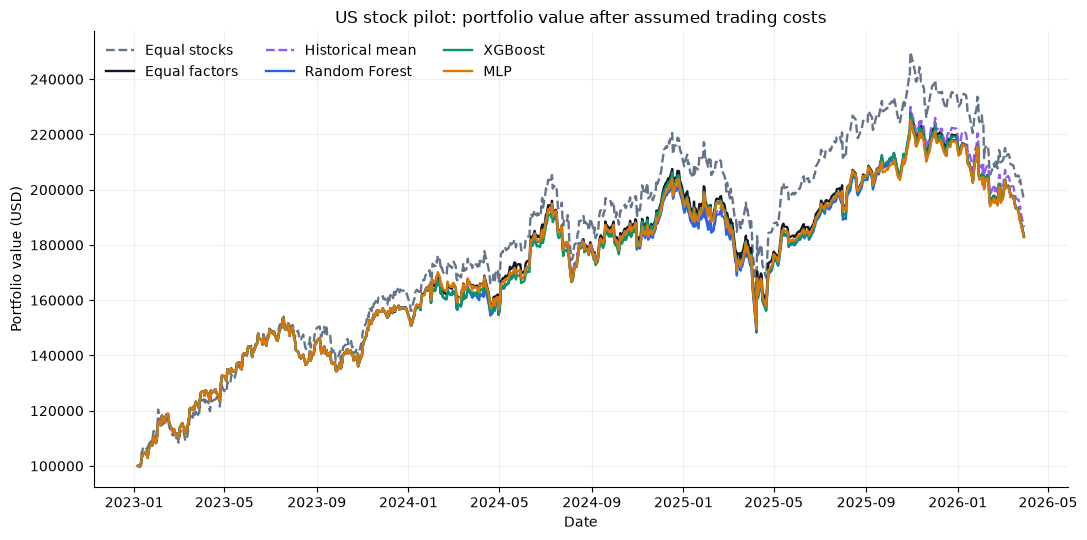

In [11]:
colors = {'Equal stocks': '#64748b', 'Equal factors': '#111827', 'Historical mean': '#8b5cf6', 'Random Forest': '#2563eb', 'XGBoost': '#059669', 'MLP': '#d97706'}
fig, ax = plt.subplots(figsize=(11, 5.5))
for name in portfolio_values:
    ax.plot(portfolio_values.index, portfolio_values[name], label=name, color=colors[name], linewidth=1.7, linestyle='--' if name in ['Equal stocks', 'Historical mean'] else '-')
ax.set(title='US stock pilot: portfolio value after assumed trading costs', xlabel='Date', ylabel='Portfolio value (USD)')
ax.grid(alpha=0.2)
ax.legend(ncol=3, frameon=False, loc='upper left')
fig.tight_layout()
fig.savefig(RESULTS / 'portfolio_comparison.png', dpi=160)
plt.show()

We calculate annual volatility and the Sharpe ratio from weekly portfolio changes, using 52 weeks per year. This avoids treating a gap of several days as a single daily return. We leave an unfinished final week out of those two calculations. The Sharpe ratio uses a zero reference rate here, not the historical US risk-free rate. Direction accuracy combines three related forecasts from each test period, so these observations are not independent evidence of statistical significance.

The next table shows the forecasts from the last date with usable inputs. They are saved historical predictions, not live signals or measured outcomes. Each one covers the next scheduled four-week holding period.

Amazon's saved prices have a gap in late April and early May 2026. That leaves a missing week and stops us from getting the full 52-week volatility history for later signals. The files contain prices through September, but the usable forecasts and completed tests end earlier.

In [12]:
latest = predictions.loc[predictions.signal == X.index[-1], ['signal', 'entry', 'model', 'factor', 'predicted_return', 'trend']].copy()
latest['Predicted return %'] = latest.pop('predicted_return') * 100
display(latest.set_index(['model', 'factor']).style.format({'Predicted return %': '{:.2f}'}))
latest.to_csv(RESULTS / 'latest_prediction.csv', index=False)
X.to_csv(RESULTS / 'model_inputs.csv')
Y.to_csv(RESULTS / 'model_targets.csv')

We used Eulerpool's price and income-statement data and its API documentation for this experiment.

There are several limits to the results. We selected three large companies that are still trading, which leaves us exposed to survivorship bias. Some financial figures may have been revised, and our market values use approximate share counts. We also removed dates with conflicting prices and have not confirmed the dividend adjustments. Waiting six months before using a financial statement helps with reporting delays, but it does not solve all these problems.

This experiment looks at changing factor weights in US stocks. It does not tell us whether the approach works in emerging markets. We have not tested a regime detector, a cash rule or the alternative factor measures from the proposal here. Those need separate experiments after we check the data further.

We tested Apple, Microsoft and Amazon over 42 four-week periods, from 9 January 2023 to 30 March 2026. After the assumed trading costs, Random Forest returned 20.57% a year, XGBoost 20.64% and MLP 20.54%. Equal stock weights returned 23.24%, and equal factor weights returned 20.66%. None of the three ML models beat those two approaches in this run. Their direction accuracy was about 52%, compared with 60.32% for the forecast based on historical averages. The factor portfolios were very similar: at least two held the same stocks in 38 of the 42 periods. We now have a working first experiment, but these results do not show an improvement from ML. We used earnings yield, profit margin and momentum because the original balance-sheet measures need better data. Missing prices also shortened the usable test period. Our next step should be to check the financial data and try a larger group of stocks. Changing the models just to improve the same test results would not answer our research question.

We then add a small LSTM and a one-dimensional CNN using PyTorch. Each model gets the same factor inputs from the past eight weeks and predicts the three portfolios' returns over the next four weeks. A positive prediction is labelled Up. Otherwise, it is labelled Down.

We also rerun Random Forest, XGBoost and MLP using the same eight weeks of inputs, placed in separate columns. All five models use the same training observations and 42 test periods. We calculate the historical-average forecasts again using that same training sample. The earlier results belong to the first run, where the models used only the current row of inputs.

The LSTM has eight hidden units. The CNN has eight filters, a three-week kernel and average pooling. We train both for 80 epochs using Adam, with a learning rate of 0.001 and weight decay of 0.01. We scale inputs and target returns using the training data only, then convert predictions back to returns before ranking the factors. Every fit starts with fresh weights and a random seed of 42.

We added this comparison after seeing the first experiment. We chose these settings before the deep learning run and did not adjust them using its results. We have only tried one seed and three stocks, so this is still an early comparison.

In [13]:
import torch
from torch import nn

torch.set_num_threads(1)
torch.use_deterministic_algorithms(True)
LOOKBACK = 8
EPOCHS = 80
sequence_dates = X.index[LOOKBACK - 1:]
sequences = np.stack([X.iloc[i-LOOKBACK+1:i+1].to_numpy() for i in range(LOOKBACK-1, len(X))])
sequence_y = Y.loc[sequence_dates]
sequence_end = label_end.loc[sequence_dates]
if not test_dates.isin(sequence_dates).all():
    raise ValueError('The models must use the original test dates.')
if not X.index.to_series().diff().dropna().eq(pd.Timedelta(weeks=1)).all():
    raise ValueError('The input sequence contains a missing week.')
print(f'{len(sequences)} eight-week sequences; {len(test_dates)} common test periods.')

491 eight-week sequences; 42 common test periods.


In [14]:
class SmallLSTM(nn.Module):
    def __init__(self, features):
        super().__init__()
        self.lstm = nn.LSTM(features, 8, batch_first=True)
        self.output = nn.Linear(8, 3)

    def forward(self, values):
        history, state = self.lstm(values)
        return self.output(history[:, -1])

class SmallCNN(nn.Module):
    def __init__(self, features):
        super().__init__()
        self.layers = nn.Sequential(nn.Conv1d(features, 8, 3), nn.ReLU(), nn.AdaptiveAvgPool1d(1), nn.Flatten(), nn.Linear(8, 3))

    def forward(self, values):
        return self.layers(values.transpose(1, 2))

def fit_deep(model_class, train_x, train_y, test_x):
    torch.manual_seed(42)
    feature_scaler = StandardScaler().fit(train_x.reshape(-1, train_x.shape[-1]))
    target_scaler = StandardScaler().fit(train_y)
    scaled_train = feature_scaler.transform(train_x.reshape(-1, train_x.shape[-1])).reshape(train_x.shape)
    scaled_test = feature_scaler.transform(test_x.reshape(-1, test_x.shape[-1])).reshape(test_x.shape)
    inputs = torch.tensor(scaled_train, dtype=torch.float32)
    targets = torch.tensor(target_scaler.transform(train_y), dtype=torch.float32)
    model = model_class(train_x.shape[-1])
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=0.01)
    loss_function = nn.MSELoss()
    losses = []
    model.train()
    for epoch in range(EPOCHS):
        optimizer.zero_grad()
        loss = loss_function(model(inputs), targets)
        if not torch.isfinite(loss):
            raise ValueError('The model loss is not finite.')
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    model.eval()
    with torch.no_grad():
        output = model(torch.tensor(scaled_test, dtype=torch.float32)).numpy()
    return target_scaler.inverse_transform(output)[0], losses

In [15]:
history_predictions = []
history_training = []
history_warnings = []
training_losses = []
history_run_dates = test_dates.union(pd.DatetimeIndex([sequence_dates[-1]]))
for signal in history_run_dates:
    eligible = (sequence_dates < signal) & sequence_end.lt(signal) & sequence_y.notna().all(axis=1)
    train_x = sequences[eligible.to_numpy()]
    train_y = sequence_y.loc[eligible].to_numpy()
    test_x = sequences[[sequence_dates.get_loc(signal)]]
    history_training.append({'signal': signal, 'training_sequences': len(train_x), 'latest_training_exit': sequence_end.loc[eligible].max()})
    forecasts = {'Historical mean (8 weeks)': train_y.mean(axis=0)}
    for name, model in make_models().items():
        with warnings.catch_warnings(record=True) as caught:
            warnings.simplefilter('always', ConvergenceWarning)
            model.fit(train_x.reshape(len(train_x), -1), train_y)
        history_warnings.extend({'signal': signal, 'model': name, 'warning': str(item.message)} for item in caught)
        forecasts[f'{name} (8 weeks)'] = model.predict(test_x.reshape(1, -1))[0]
    for name, model_class in [('LSTM', SmallLSTM), ('CNN', SmallCNN)]:
        forecasts[name], losses = fit_deep(model_class, train_x, train_y, test_x)
        training_losses.extend({'signal': signal, 'model': name, 'epoch': i+1, 'training_mse_scaled': value} for i, value in enumerate(losses))
    for name, values in forecasts.items():
        for factor, value in zip(FACTORS, values):
            history_predictions.append({'signal': signal, 'entry': execution_dates[signal], 'exit': label_end.loc[signal], 'model': name, 'factor': factor, 'predicted_return': value, 'actual_return': Y.loc[signal, factor], 'trend': 'Up' if value > 0 else 'Down', 'completed_test': signal in test_dates})

history_predictions = pd.DataFrame(history_predictions)
history_predictions.to_csv(RESULTS / 'deep_predictions.csv', index=False)
pd.DataFrame(history_training).to_csv(RESULTS / 'deep_training_dates.csv', index=False)
pd.DataFrame(training_losses).to_csv(RESULTS / 'deep_training_losses.csv', index=False)
pd.DataFrame(history_warnings, columns=['signal', 'model', 'warning']).to_csv(RESULTS / 'deep_fit_warnings.csv', index=False)
print(f'Finished the common-history comparison. Fitting warnings: {len(history_warnings)}.')

Finished the common-history comparison. Fitting warnings: 0.


We measure direction accuracy over the same completed test periods for each model. Return errors are shown in percentage points. There are 126 forecasts, but the portfolios share stocks, so those forecasts are related. We should not treat them as 126 independent tests.

In [16]:
history_accuracy = []
for name, group in history_predictions.loc[history_predictions.completed_test].groupby('model', sort=False):
    history_accuracy.append({'Model': name, 'Direction accuracy %': 100 * (group.predicted_return.gt(0) == group.actual_return.gt(0)).mean(), 'MAE percentage points': 100 * (group.predicted_return - group.actual_return).abs().mean(), 'Basket forecasts': len(group)})
history_accuracy = pd.DataFrame(history_accuracy).set_index('Model')
history_accuracy.to_csv(RESULTS / 'deep_forecast_accuracy.csv')
display(history_accuracy.round(2))

,Direction accuracy %,MAE percentage points,Basket forecasts
Model,,,
Historical mean (8 weeks),60.3200,3.9100,126
Random Forest (8 weeks),55.5600,4.2000,126
XGBoost (8 weeks),53.9700,4.1500,126
MLP (8 weeks),47.6200,6.3300,126
LSTM,60.3200,4.1000,126
CNN,56.3500,4.1200,126


For this comparison, we keep the same 50%, 30% and 20% allocation rule, trade dates, starting amount and trading costs. The equal-stock and equal-factor portfolios also stay the same. This lets us see what changes when we change the model while keeping the portfolio rules fixed.

In [17]:
history_names = history_accuracy.index.tolist()
history_weight_rows = []
for signal in test_dates:
    for name in history_names:
        values = history_predictions.loc[(history_predictions.signal == signal) & (history_predictions.model == name)].set_index('factor').predicted_return.reindex(FACTORS)
        ranked = values.sort_values(ascending=False, kind='stable').index
        factor_weights = pd.Series([0.5, 0.3, 0.2], index=ranked).reindex(FACTORS)
        weights = bucket_weights[signal].dot(factor_weights)
        portfolio_weights[(signal, name)] = weights
        history_weight_rows.append({'signal': signal, 'strategy': name, **weights.to_dict()})

history_values = [portfolio_values['Equal stocks'], portfolio_values['Equal factors']]
history_trade_rows = []
for name in history_names:
    nav, trades_for_model = backtest(name)
    history_values.append(nav)
    history_trade_rows.extend(trades_for_model)
history_values = pd.concat(history_values, axis=1)
history_trades = pd.DataFrame(history_trade_rows)
history_performance = []
for name in history_values:
    nav = history_values[name]
    years = (nav.index[-1] - nav.index[0]).days / 365.25
    weekly_nav = nav.resample('W-FRI').last()
    weekly_nav = weekly_nav.loc[weekly_nav.index <= nav.index[-1]]
    changes = weekly_nav.pct_change(fill_method=None).dropna()
    cost = performance.loc[name, 'Trading costs USD'] if name in ['Equal stocks', 'Equal factors'] else history_trades.loc[history_trades.strategy == name, 'cost_usd'].sum()
    history_performance.append({'Strategy': name, 'Annual return %': 100 * ((nav.iloc[-1] / INITIAL_VALUE) ** (1 / years) - 1), 'Cumulative return %': 100 * (nav.iloc[-1] / INITIAL_VALUE - 1), 'Volatility %': 100 * changes.std() * np.sqrt(52), 'Max drawdown %': 100 * (nav / nav.cummax() - 1).min(), 'Sharpe (0% reference)': changes.mean() / changes.std() * np.sqrt(52), 'Final value USD': nav.iloc[-1], 'Trading costs USD': cost})
history_performance = pd.DataFrame(history_performance).set_index('Strategy')
history_performance.to_csv(RESULTS / 'deep_performance.csv')
history_values.to_csv(RESULTS / 'deep_portfolio_values.csv', index_label='date')
history_trades.to_csv(RESULTS / 'deep_trading_costs.csv', index=False)
pd.DataFrame(history_weight_rows).to_csv(RESULTS / 'deep_stock_weights.csv', index=False)
display(history_performance.round(2))

,Annual return %,Cumulative return %,Volatility %,Max drawdown %,Sharpe (0% reference),Final value USD,Trading costs USD
Strategy,,,,,,,
Equal stocks,23.2400,96.3000,19.8600,-25.9000,1.1900,"196,295.7400",346.7600
Equal factors,20.6600,83.3700,19.6600,-26.9300,1.0900,"183,365.7300","1,058.6600"
Historical mean (8 weeks),21.2900,86.4800,19.8100,-26.7400,1.1100,"186,476.5400","1,143.7800"
Random Forest (8 weeks),19.9600,79.9200,19.7700,-27.2600,1.0600,"179,917.7000","1,293.8800"
XGBoost (8 weeks),19.6000,78.1800,19.9300,-27.6900,1.0400,"178,178.4600","1,439.2400"
MLP (8 weeks),21.0500,85.2600,19.7500,-26.7400,1.1100,"185,263.6100","1,483.3200"
LSTM,20.2500,81.3200,19.4300,-27.2100,1.0900,"181,322.4400",975.8700
CNN,22.2000,91.0200,19.6100,-25.9600,1.1600,"191,016.6700","1,375.5000"


C:\Users\Arian\AppData\Local\Temp\ipykernel_24120\1744025987.py:16: UserWarning: AutoDateLocator was unable to pick an appropriate interval for this date range. It may be necessary to add an interval value to the AutoDateLocator's intervald dictionary. Defaulting to 6.
  fig.tight_layout()
C:\Users\Arian\AppData\Local\Temp\ipykernel_24120\1744025987.py:17: UserWarning: AutoDateLocator was unable to pick an appropriate interval for this date range. It may be necessary to add an interval value to the AutoDateLocator's intervald dictionary. Defaulting to 6.
  fig.savefig(RESULTS / 'deep_learning_comparison.png', dpi=160)


F:\Capstone Project\Trend Prediction Experiment\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: AutoDateLocator was unable to pick an appropriate interval for this date range. It may be necessary to add an interval value to the AutoDateLocator's intervald dictionary. Defaulting to 6.
  fig.canvas.print_figure(bytes_io, **kw)


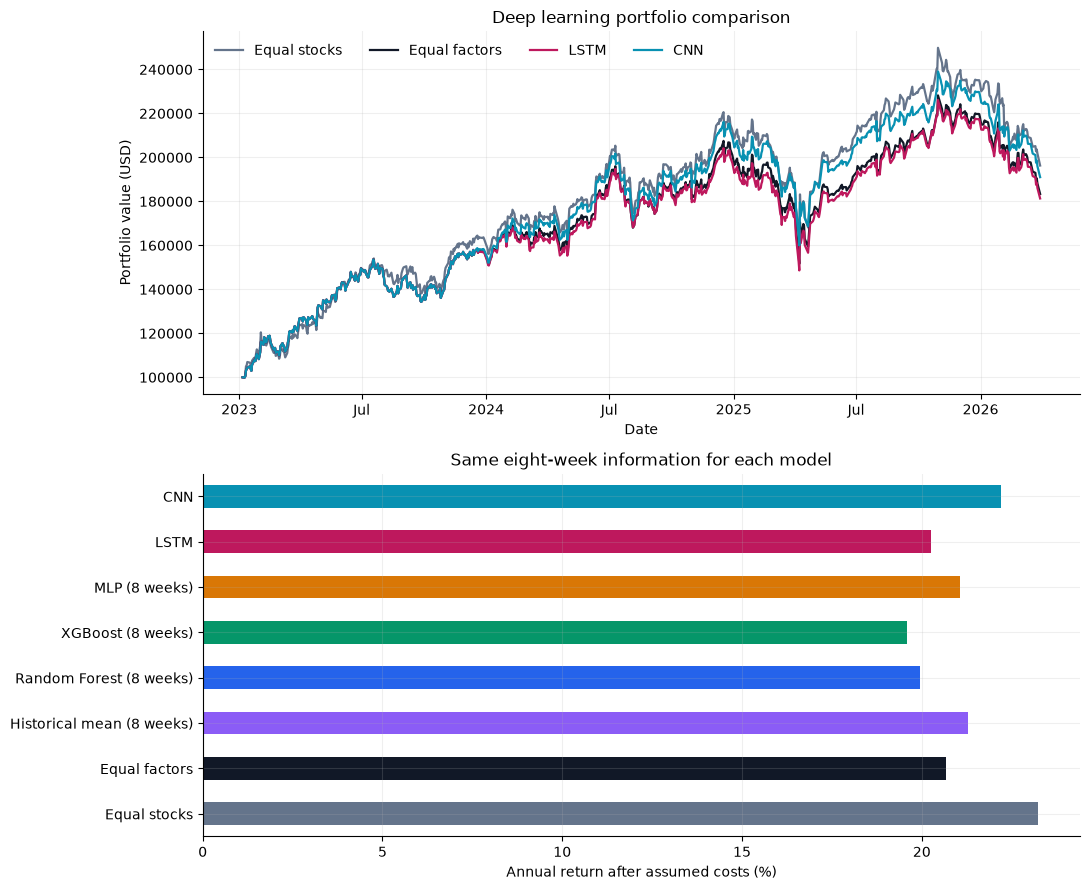

In [18]:
from matplotlib.dates import AutoDateLocator, ConciseDateFormatter

history_colors = {'Equal stocks': '#64748b', 'Equal factors': '#111827', 'Historical mean (8 weeks)': '#8b5cf6', 'Random Forest (8 weeks)': '#2563eb', 'XGBoost (8 weeks)': '#059669', 'MLP (8 weeks)': '#d97706', 'LSTM': '#be185d', 'CNN': '#0891b2'}
fig, axes = plt.subplots(2, 1, figsize=(11, 9))
for name in ['Equal stocks', 'Equal factors', 'LSTM', 'CNN']:
    axes[0].plot(history_values.index, history_values[name], label=name, color=history_colors[name], linewidth=1.6)
locator = AutoDateLocator(minticks=4, maxticks=6)
axes[0].xaxis.set_major_locator(locator)
axes[0].xaxis.set_major_formatter(ConciseDateFormatter(locator))
axes[0].set(title='Deep learning portfolio comparison', xlabel='Date', ylabel='Portfolio value (USD)')
axes[0].legend(frameon=False, ncol=4)
history_performance['Annual return %'].plot.barh(ax=axes[1], color=[history_colors[name] for name in history_performance.index])
axes[1].set(title='Same eight-week information for each model', xlabel='Annual return after assumed costs (%)', ylabel='')
for ax in axes:
    ax.grid(alpha=0.2)
fig.tight_layout()
fig.savefig(RESULTS / 'deep_learning_comparison.png', dpi=160)
plt.show()

In [19]:
last_deep = history_predictions.loc[(history_predictions.signal == sequence_dates[-1]) & history_predictions.model.isin(['LSTM', 'CNN']), ['signal', 'entry', 'model', 'factor', 'predicted_return', 'trend']].copy()
last_deep['Predicted return %'] = last_deep.pop('predicted_return') * 100
display(last_deep.set_index(['model', 'factor']).style.format({'Predicted return %': '{:.2f}'}))
last_deep.to_csv(RESULTS / 'deep_latest_prediction.csv', index=False)

The last table shows saved forecasts using the same historical data cutoff as the first experiment. These are not live predictions. The gaps in prices and limits of the financial data still matter here.

The CNN returned 22.20% a year after the assumed costs. That was the highest return among the five learned models using eight weeks of history, but equal stock weights still did better at 23.24%. The LSTM returned 20.25%. Its direction accuracy was 60.32%, the same as the historical-average forecast. However, both predicted Up in every completed test, so that score does not show that they can spot falling periods. The CNN had a lower direction accuracy of 56.35% but a higher portfolio return than the LSTM. This is why we need to check the portfolio results as well as prediction accuracy. We have only tested three stocks over 42 periods, and the factor portfolios often held the same companies. These results help us compare the models, but they are not enough to conclude that either deep learning model is a better investment method.